In [1]:
import pandas as pd
df= pd.read_csv("zameen.csv")
df=df.loc[~((df['Baths']=='-') | (df['Bedrooms']=='-'))]
df['Baths'] = pd.to_numeric(df['Baths'], errors='coerce')
df['Bedrooms'] = pd.to_numeric(df['Bedrooms'], errors='coerce')
df.dropna(inplace=True)
print(df)

            Area  Baths  Bedrooms          Price  \
0       18 Marla    6.0         5    PKR15 Crore   
2        1 Kanal    7.0         6    PKR12 Crore   
3        1 Kanal    7.0         6  PKR11.9 Crore   
4     11.9 Marla    4.0         3   PKR3.2 Crore   
5        1 Kanal    6.0         6   PKR7.7 Crore   
...          ...    ...       ...            ...   
1183     6 Marla    4.0         4   PKR5.5 Crore   
1184     6 Marla    5.0         5   PKR5.5 Crore   
1185  14.2 Marla    6.0         6   PKR9.5 Crore   
1186     6 Marla    5.0         4   PKR4.5 Crore   
1187   6.6 Marla    4.0         4  PKR5.45 Crore   

                                       location  
0     DHA Defence, Islamabad, Islamabad Capital  
2     DHA Defence, Islamabad, Islamabad Capital  
3     DHA Defence, Islamabad, Islamabad Capital  
4     DHA Defence, Islamabad, Islamabad Capital  
5     DHA Defence, Islamabad, Islamabad Capital  
...                                         ...  
1183          G-9, Islama

In [2]:
import numpy as np
price = df['Price'].astype(str).to_numpy().astype('U')
price = np.char.replace(price, 'PKR', '')
price=np.char.split(price,' ')
values = np.array([float(x[0]) for x in price])
units = np.array([x[1] for x in price])
df['Price'] = np.where((units =='Crore'),values, np.where((units =='Arab'),values*100,values*0.01))

In [3]:
area = df['Area'].astype(str).to_numpy().astype('U')
area=np.char.split(area,' ')
values = np.array([float(x[0]) for x in area])
units = np.array([x[1] for x in area])
df['Area'] = np.where((units =='Kanal'),values,values/20)


In [4]:
location_map = {
    'B-17, Islamabad, Islamabad Capital': 1,
    'Bahria Town, Islamabad, Islamabad Capital': 2,
    'D-12, Islamabad, Islamabad Capital': 3,
    'DHA Defence, Islamabad, Islamabad Capital': 4,
    'E-11, Islamabad, Islamabad Capital': 5,
    'F-10, Islamabad, Islamabad Capital': 6,
    'F-11, Islamabad, Islamabad Capital': 7,
    'F-6, Islamabad, Islamabad Capital': 8,
    'F-7, Islamabad, Islamabad Capital': 9,
    'F-8, Islamabad, Islamabad Capital': 10,
    'FECHS, Islamabad, Islamabad Capital': 11,
    'G-11, Islamabad, Islamabad Capital': 12,
    'G-13, Islamabad, Islamabad Capital': 13,
    'G-6, Islamabad, Islamabad Capital':14,
    'G-7, Islamabad, Islamabad Capital':15,
    'G-8, Islamabad, Islamabad Capital':16,
    'G-9, Islamabad, Islamabad Capital':17, 
    'Gulberg, Islamabad, Islamabad Capital': 18,
    'Naval Anchorage, Islamabad, Islamabad Capital':19,
    'PWD Housing Scheme, Islamabad, Islamabad Capital': 20,
    'Soan Garden, Islamabad, Islamabad Capital': 21
}
df['Location_Code'] = df['location'].map(location_map)
print(df)

       Area  Baths  Bedrooms  Price  \
0     0.900    6.0         5  15.00   
2     1.000    7.0         6  12.00   
3     1.000    7.0         6  11.90   
4     0.595    4.0         3   3.20   
5     1.000    6.0         6   7.70   
...     ...    ...       ...    ...   
1183  0.300    4.0         4   5.50   
1184  0.300    5.0         5   5.50   
1185  0.710    6.0         6   9.50   
1186  0.300    5.0         4   4.50   
1187  0.330    4.0         4   5.45   

                                       location  Location_Code  
0     DHA Defence, Islamabad, Islamabad Capital              4  
2     DHA Defence, Islamabad, Islamabad Capital              4  
3     DHA Defence, Islamabad, Islamabad Capital              4  
4     DHA Defence, Islamabad, Islamabad Capital              4  
5     DHA Defence, Islamabad, Islamabad Capital              4  
...                                         ...            ...  
1183          G-9, Islamabad, Islamabad Capital             17  
1184       

In [5]:
df_shuffled = df.sample(frac=1, random_state=42)
train_size = int(0.8 * len(df))
train_df = df_shuffled[:train_size]
test_df = df_shuffled[train_size:]
x1=(train_df['Area']-train_df['Area'].mean())/train_df['Area'].std()
x2=(train_df['Location_Code']-train_df['Location_Code'].mean())/train_df['Location_Code'].std()
ss=x1.shape[0]
x=np.c_[x1,x2,np.ones(ss)]
print(x.shape)

(884, 3)


In [6]:
y=np.array(train_df['Price'])
learning_rate=0.02
epoches=2000
N=y.size
np.random.seed(123)
coeff=np.random.rand(3)
print(coeff)

def alg(x,y,coeff,epoches,learning_rate):
    past_cost=[]
    past_coeff=[coeff]
    for i in range(epoches):
        pred=np.dot(x,coeff)
        error = pred-y
        cost=1/(2*N) *np.dot(error.T,error)
        past_cost.append(cost)
        der=1/N * learning_rate * np.dot(x.T,error)
        coeff =coeff-der
        past_coeff.append(coeff)
    return past_coeff,past_cost
past_coeff,past_cost=alg(x,y,coeff,epoches,learning_rate)
coeff=past_coeff[-1]
print("Final Coeff values are :",coeff)

[0.69646919 0.28613933 0.22685145]
Final Coeff values are : [16.32947635  0.71297414 12.60146324]


In [7]:
y_pred_train = np.dot(x, coeff)
mse = np.mean((y - y_pred_train) ** 2)
print("Training MSE:", mse)
test_y=np.array(test_df['Price'])
test_x1=(test_df['Area']-train_df['Area'].mean())/train_df['Area'].std()
test_x2=(test_df['Location_Code']-train_df['Location_Code'].mean())/train_df['Location_Code'].std()
pred_y=coeff[0]*test_x1 + coeff[1]*test_x2 + coeff[2]
rmse = np.sqrt(np.mean((test_y - pred_y) ** 2))
print("Test RMSE:", rmse)
r2=1- ((np.sum((test_y -pred_y)**2))/(np.sum((test_y -np.mean(pred_y))**2)))
print("R-2:",r2)

Training MSE: 79.74612036400067
Test RMSE: 8.117021903981197
R-2: 0.532912517780666


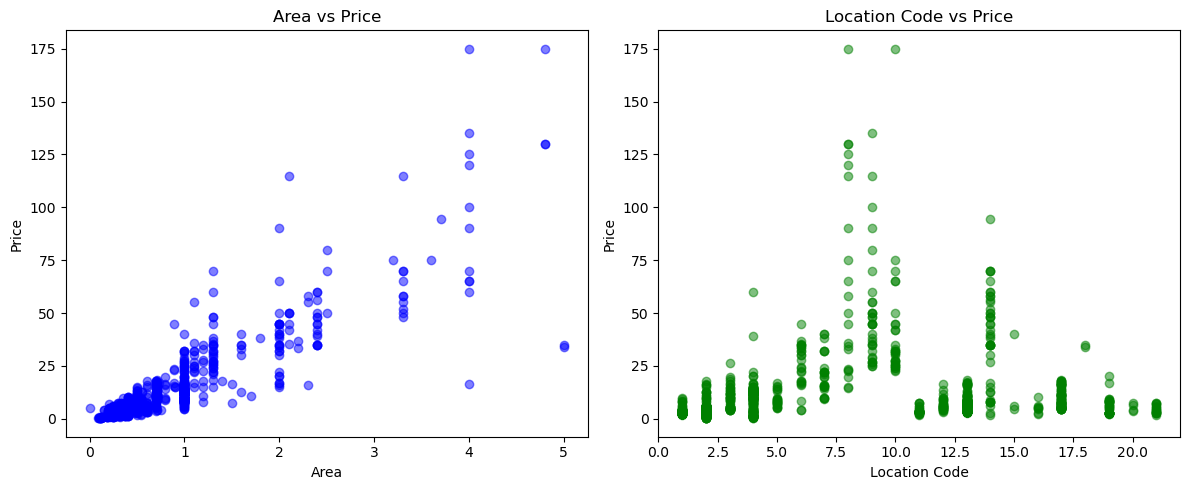

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(df['Area'], df['Price'], color='blue', alpha=0.5)
plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.subplot(1,2,2)
plt.scatter(df['Location_Code'], df['Price'], color='green', alpha=0.5)
plt.title("Location Code vs Price")
plt.xlabel("Location Code")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

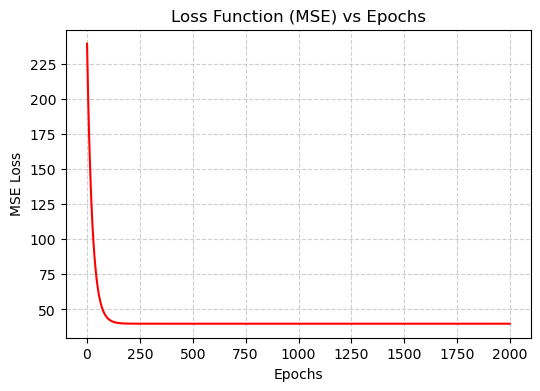

In [9]:
plt.figure(figsize=(6,4))
plt.plot(past_cost, color='red')
plt.title("Loss Function (MSE) vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


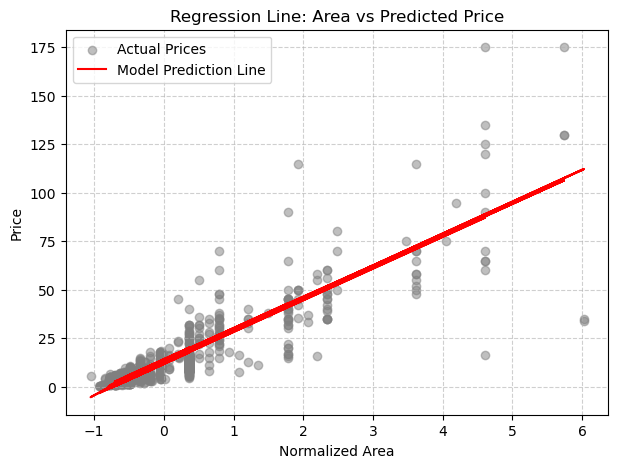

In [10]:
x1 = (df['Area'] - df['Area'].mean()) / df['Area'].std()
x2 =((df['Location_Code']-df['Location_Code'].mean())/df['Location_Code'].std())
predicted_price = coeff[0]*x1 + coeff[1]*x2 + coeff[2]
plt.figure(figsize=(7,5))
plt.scatter(x1, df['Price'], color='gray', alpha=0.5, label='Actual Prices')
plt.plot(x1, predicted_price, color='red', label='Model Prediction Line')
plt.title("Regression Line: Area vs Predicted Price")
plt.xlabel("Normalized Area")
plt.ylabel("Price")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()